In [1]:
# KPI : Gravité jour vs nuit
import pandas as pd
import numpy as np

# 1) Charger les données
df = pd.read_csv("E:/us_cleaned.csv")

# 2) Construire la variable Jour/Nuit
# Priorité à Sunrise_Sunset si elle existe, sinon Civil_Twilight
day_col = None
for c in ["Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]:
    if c in df.columns:
        day_col = c
        break

if day_col is None:
    raise ValueError("Aucune colonne Twilight/Sunrise_Sunset trouvée pour calculer Jour vs Nuit.")

df_daynight = df.dropna(subset=[day_col, "Severity"]).copy()
df_daynight["DayNight"] = (
    df_daynight[day_col]
    .astype(str)
    .str.strip()
    .str.title()
)

# garder uniquement Day / Night
df_daynight = df_daynight[df_daynight["DayNight"].isin(["Day", "Night"])]

# 3) KPI : gravité moyenne jour vs nuit
kpi_daynight = df_daynight.groupby("DayNight")["Severity"].agg(
    nb_accidents="count",
    gravite_moyenne="mean",
    gravite_mediane="median"
).reset_index()

kpi_daynight


,DayNight,nb_accidents,gravite_moyenne,gravite_mediane
0,Day,364395,2.364124,2.0
1,Night,135583,2.403126,2.0


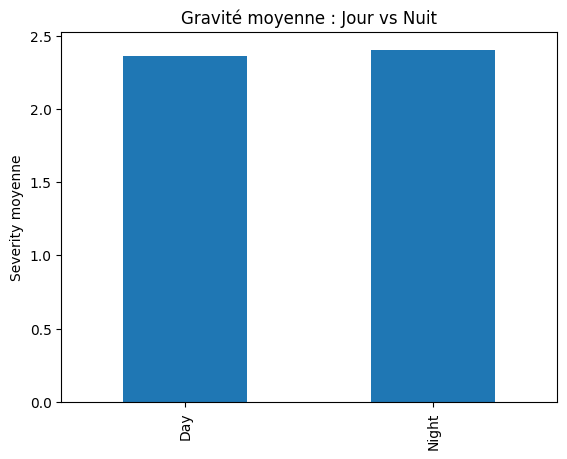

In [2]:
import matplotlib.pyplot as plt

ax = kpi_daynight.plot(kind="bar", x="DayNight", y="gravite_moyenne", legend=False)
plt.title("Gravité moyenne : Jour vs Nuit")
plt.xlabel("")
plt.ylabel("Severity moyenne")
plt.show()

In [3]:
# KPI : Accidents aux carrefours
kpi_junction = (
    df["Junction"]
    .value_counts(dropna=False)
    .rename_axis("Junction")
    .reset_index(name="nb_accidents")
)

# Calcul de la part en %
kpi_junction["part_%"] = (
    kpi_junction["nb_accidents"] / kpi_junction["nb_accidents"].sum()
) * 100

kpi_junction


,Junction,nb_accidents,part_%
0,False,468077,93.6154
1,True,31923,6.3846


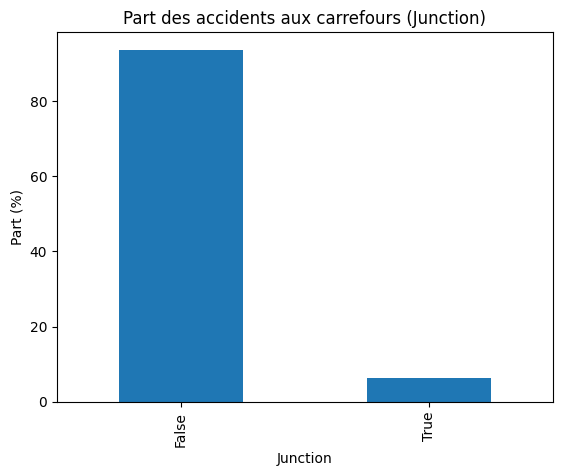

In [4]:
ax = kpi_junction.set_index("Junction")["part_%"].plot(kind="bar")
plt.title("Part des accidents aux carrefours (Junction)")
plt.xlabel("Junction")
plt.ylabel("Part (%)")
plt.show()

In [5]:
#KPI : Accidents aux feux (Traffic_Signal)
if "Traffic_Signal" not in df.columns:
    raise ValueError("Colonne 'Traffic_Signal' introuvable.")

df_t = df.dropna(subset=["Traffic_Signal"]).copy()
kpi_signal = df_t["Traffic_Signal"].value_counts(dropna=False).rename_axis("Traffic_Signal").reset_index(name="nb_accidents")
kpi_signal["part_%"] = 100 * kpi_signal["nb_accidents"] / kpi_signal["nb_accidents"].sum()
kpi_signal

,Traffic_Signal,nb_accidents,part_%
0,False,385083,77.0166
1,True,114917,22.9834


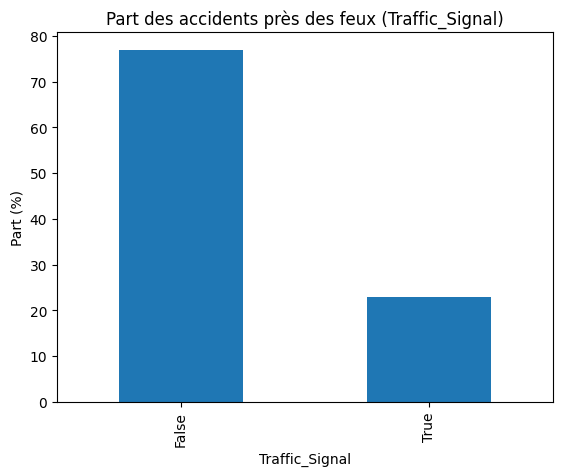

In [6]:
ax = kpi_signal.set_index("Traffic_Signal")["part_%"].plot(kind="bar")
plt.title("Part des accidents près des feux (Traffic_Signal)")
plt.xlabel("Traffic_Signal")
plt.ylabel("Part (%)")
plt.show()

In [7]:
#KPI : Conditions cumulées à risque (météo + nuit + faible visibilité)
needed = ["Severity", "Weather_Condition"]
for col in needed:
    if col not in df.columns:
        raise ValueError(f"Colonne manquante: {col}")

df_risk = df.copy()

# Jour/Nuit si dispo
if day_col is not None and day_col in df_risk.columns:
    df_risk["DayNight"] = df_risk[day_col].astype(str).str.strip().str.title()
else:
    df_risk["DayNight"] = np.nan

# faible visibilité
if "Visibility(mi)" in df_risk.columns:
    # seuil simple : 25e percentile (adaptatif)
    vis_thr = df_risk["Visibility(mi)"].dropna().quantile(0.25)
    df_risk["low_visibility"] = df_risk["Visibility(mi)"] <= vis_thr
else:
    df_risk["low_visibility"] = np.nan

# météo défavorable (rain/snow)
w = df_risk["Weather_Condition"].astype(str).str.lower()
df_risk["bad_weather"] = w.str.contains("rain|snow|storm|sleet|hail|fog", regex=True)

# nuit
df_risk["is_night"] = (df_risk["DayNight"] == "Night")

# score de risque simple (0 à 3)
df_risk["risk_score"] = df_risk[["bad_weather", "is_night", "low_visibility"]].sum(axis=1)

# taux d’accidents graves par niveau de risque
df_risk["accident_grave"] = (df_risk["Severity"] >= 3).astype(int)

kpi_risk = df_risk.dropna(subset=["risk_score", "accident_grave"]).groupby("risk_score")["accident_grave"].agg(
    nb="count",
    taux_grave="mean"
).reset_index()

kpi_risk["taux_grave_%"] = 100 * kpi_risk["taux_grave"]
kpi_risk

,risk_score,nb,taux_grave,taux_grave_%
0,0,2330,0.455794,45.579399
1,1,337646,0.361227,36.122744
2,2,149081,0.399139,39.913872
3,3,10943,0.449602,44.960249


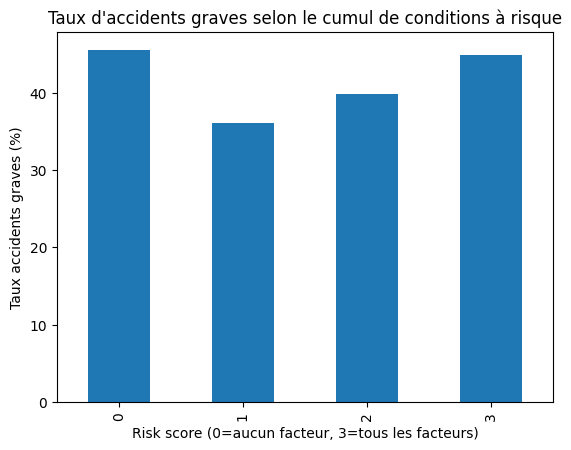

In [8]:
ax = kpi_risk.plot(kind="bar", x="risk_score", y="taux_grave_%", legend=False)
plt.title("Taux d'accidents graves selon le cumul de conditions à risque")
plt.xlabel("Risk score (0=aucun facteur, 3=tous les facteurs)")
plt.ylabel("Taux accidents graves (%)")
plt.show()